In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../database/air_quality.db")

In [3]:
query = "SELECT * FROM air_quality"

df = pd.read_sql_query(query, conn)

df.head()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,calculated_aqi,primary_pollutant,notified
0,1,2026-07-17 14:54:48,4,64.12,66.66,508.77,3.62,129.69,4.91,155.0,pm2_5,0
1,2,2026-07-17 14:55:44,4,64.12,66.66,508.77,3.62,129.69,4.91,155.0,pm2_5,0
2,3,2026-07-17 15:00:02,4,64.12,66.66,508.77,3.62,129.69,4.91,155.0,pm2_5,0
3,4,2026-07-17 16:03:49,4,71.83,75.19,522.48,4.51,134.23,5.20,159.0,pm2_5,0
4,5,2026-07-17 18:39:46,5,80.25,88.38,734.61,17.07,89.47,7.83,164.0,pm2_5,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 392 non-null    int64  
 1   timestamp          392 non-null    object 
 2   aqi                392 non-null    int64  
 3   pm2_5              392 non-null    float64
 4   pm10               392 non-null    float64
 5   co                 392 non-null    float64
 6   no2                392 non-null    float64
 7   o3                 392 non-null    float64
 8   so2                392 non-null    float64
 9   calculated_aqi     392 non-null    float64
 10  primary_pollutant  392 non-null    object 
 11  notified           392 non-null    int64  
dtypes: float64(7), int64(3), object(2)
memory usage: 36.9+ KB


In [5]:
df.describe()

,id,aqi,pm2_5,pm10,co,no2,o3,so2,calculated_aqi,notified
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.0
mean,196.704082,3.096939,40.429005,46.270026,590.871633,14.195434,53.767041,6.576301,108.528061,0.0
std,113.643694,0.893735,19.283820,22.484979,239.906837,8.116997,32.002585,1.961036,36.943577,0.0
min,1.000000,1.000000,7.140000,8.460000,248.980000,1.890000,0.220000,2.820000,30.000000,0.0
25%,98.750000,3.000000,27.130000,30.622500,396.345000,7.782500,30.710000,5.220000,83.000000,0.0
50%,196.500000,3.000000,37.595000,41.040000,557.480000,12.860000,51.785000,6.320000,106.500000,0.0
75%,294.250000,4.000000,52.282500,61.095000,722.377500,18.720000,74.482500,7.630000,142.250000,0.0
max,396.000000,5.000000,97.470000,119.310000,1310.840000,39.280000,146.150000,16.110000,173.000000,0.0


In [6]:
df.isnull().sum()

id                   0
timestamp            0
aqi                  0
pm2_5                0
pm10                 0
co                   0
no2                  0
o3                   0
so2                  0
calculated_aqi       0
primary_pollutant    0
notified             0
dtype: int64

In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [8]:
df.isnull().sum()

id                   0
timestamp            0
aqi                  0
pm2_5                0
pm10                 0
co                   0
no2                  0
o3                   0
so2                  0
calculated_aqi       0
primary_pollutant    0
notified             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.dtypes

id                            int64
timestamp            datetime64[ns]
aqi                           int64
pm2_5                       float64
pm10                        float64
co                          float64
no2                         float64
o3                          float64
so2                         float64
calculated_aqi              float64
primary_pollutant            object
notified                      int64
dtype: object

In [13]:
#feature engineering
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["weekday"] = df["timestamp"].dt.day_name()
df.tail()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,calculated_aqi,primary_pollutant,notified,hour,day,weekday
387,392,2026-08-22 17:03:43,3,27.13,31.15,556.25,12.41,40.02,4.84,83.0,pm2_5,0,17,22,Saturday
388,393,2026-08-22 20:03:48,4,54.33,63.84,660.02,15.77,52.63,5.97,147.0,pm2_5,0,20,22,Saturday
389,394,2026-08-22 21:03:49,4,60.50,73.91,770.14,18.71,38.90,6.49,154.0,pm2_5,0,21,22,Saturday
390,395,2026-08-22 22:10:00,4,63.42,79.46,844.76,20.47,30.07,6.97,155.0,pm2_5,0,22,22,Saturday
391,396,2026-08-22 23:03:44,4,64.21,81.28,884.88,20.54,24.13,6.75,155.0,pm2_5,0,23,22,Saturday


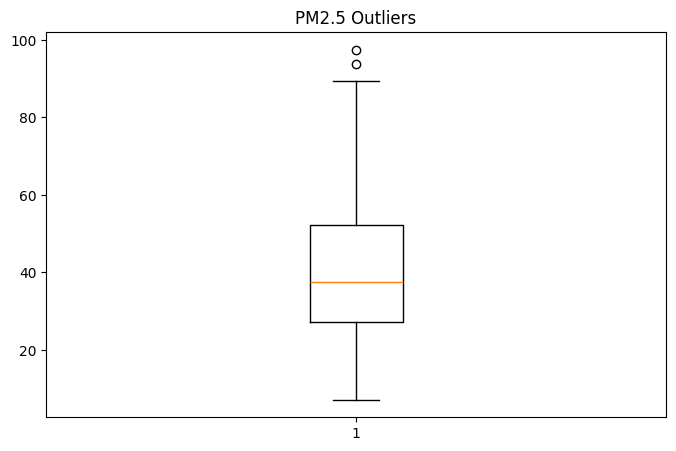

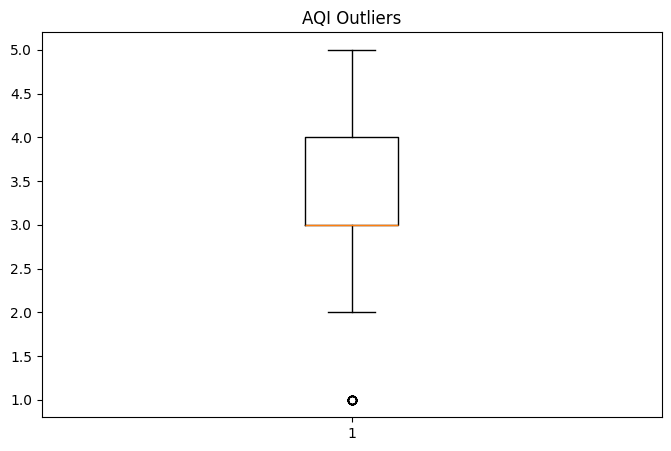

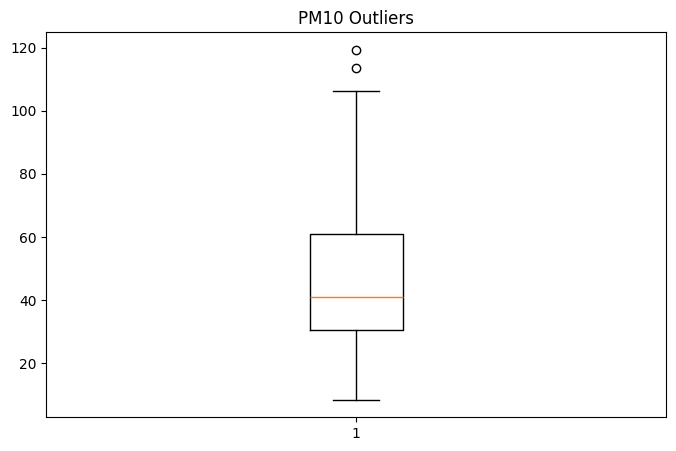

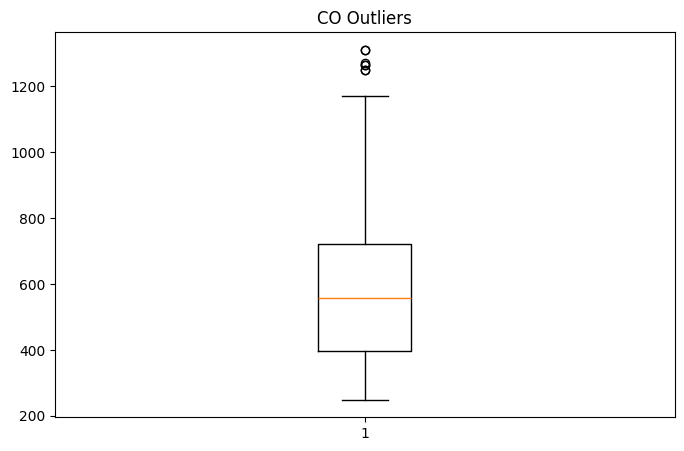

In [14]:
#checking for outliers using boxplots
plt.figure(figsize=(8,5))
plt.boxplot(df["pm2_5"])
plt.title("PM2.5 Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["aqi"])
plt.title("AQI Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["pm10"])
plt.title("PM10 Outliers")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["co"])
plt.title("CO Outliers")
plt.show()



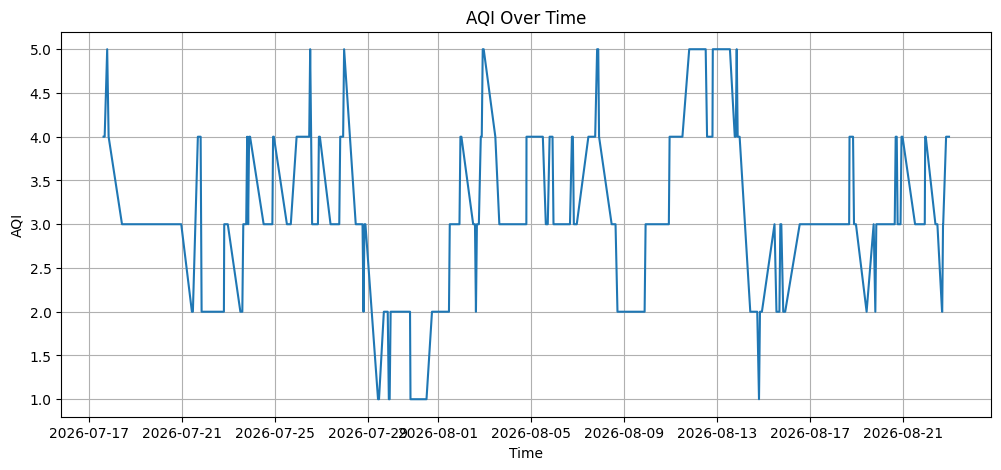

In [15]:
#aqi trend
plt.figure(figsize=(12,5))

plt.plot(df["timestamp"], df["aqi"])

plt.xlabel("Time")

plt.ylabel("AQI")

plt.title("AQI Over Time")

plt.grid(True)

plt.show()

In [16]:
#correlation matrix
corr = df.corr(numeric_only=True)
corr

,id,aqi,pm2_5,pm10,co,no2,o3,so2,calculated_aqi,notified,hour,day
id,1.000000,0.118482,0.129814,0.158548,-0.113103,-0.162928,0.160614,0.139301,0.141585,NaN,0.086724,-0.258332
aqi,0.118482,1.000000,0.932281,0.914254,0.559145,0.331358,0.111586,0.570916,0.919518,NaN,0.085195,-0.340976
pm2_5,0.129814,0.932281,1.000000,0.986574,0.602496,0.365264,0.116728,0.633154,0.974091,NaN,0.116812,-0.342817
pm10,0.158548,0.914254,0.986574,1.000000,0.663284,0.443747,0.021392,0.690068,0.959309,NaN,0.201803,-0.346848
co,-0.113103,0.559145,0.602496,0.663284,1.000000,0.901365,-0.664426,0.713463,0.620176,NaN,0.197509,-0.377214
no2,-0.162928,0.331358,0.365264,0.443747,0.901365,1.000000,-0.800696,0.723998,0.375365,NaN,0.290733,-0.242726
o3,0.160614,0.111586,0.116728,0.021392,-0.664426,-0.800696,1.000000,-0.340596,0.098247,NaN,-0.168310,0.164819
so2,0.139301,0.570916,0.633154,0.690068,0.713463,0.723998,-0.340596,1.000000,0.617884,NaN,0.295396,-0.273584
calculated_aqi,0.141585,0.919518,0.974091,0.959309,0.620176,0.375365,0.098247,0.617884,1.000000,NaN,0.098239,-0.362363
notified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df.to_csv("../data/processed_air_quality.csv",index=False)

In [18]:
df.to_sql(
    "processed_air_quality",
    conn,
    if_exists="replace",
    index=False
)

392

In [19]:
conn.close()